<a href="https://colab.research.google.com/github/nurahmi-tintyasusi-dev/DataScience_250401020035_NurahmiT/blob/main/Pertemuan10_Nurahmi_Tintyasusi_250401020035.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : NURAHMI TINTYASUSI

NIM : 250401020035

Kelas : IF401

Mata Kuliah : Data Science


---

Langkah 1 — Muat dan Eksplorasi Data

In [7]:
import urllib.request

url = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/"
    "Telco-Customer-Churn.csv"
)

urllib.request.urlretrieve(url, "telco_churn.csv")

print("Dataset berhasil diunduh.")

import pandas as pd

df = pd.read_csv("telco_churn.csv")

print(df.shape)
display(df.head())

Dataset berhasil diunduh.
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Langkah 2 — Preprocessing

In [8]:
# Membuat salinan agar data asli tidak berubah
df_clean = df.copy()

# TotalCharges biasanya terbaca sebagai object karena terdapat spasi kosong
if "TotalCharges" in df_clean.columns:
    df_clean["TotalCharges"] = pd.to_numeric(
        df_clean["TotalCharges"],
        errors="coerce"
    )

# Periksa kembali nilai kosong setelah konversi
print("Nilai kosong sebelum penanganan:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

# Mengisi nilai kosong numerik dengan median
numeric_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

Nilai kosong sebelum penanganan:
TotalCharges    11
dtype: int64


In [9]:
# Mengubah target: No=0 dan Yes=1
df_clean["Churn"] = (
    df_clean["Churn"]
    .astype(str)
    .str.strip()
    .map({"No": 0, "Yes": 1})
)

# Pastikan target berhasil dikonversi
if df_clean["Churn"].isna().any():
    raise ValueError(
        "Target Churn mengandung nilai selain 'Yes' dan 'No'."
    )

# customerID hanya merupakan identitas sehingga tidak digunakan sebagai fitur
if "customerID" in df_clean.columns:
    df_clean = df_clean.drop(columns=["customerID"])

X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"].astype(int)

# Encoding semua fitur kategorikal
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print("Ukuran fitur setelah encoding:", X.shape)
print("Distribusi target:")
print(y.value_counts(normalize=True).round(3))

Ukuran fitur setelah encoding: (7043, 30)
Distribusi target:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


Langkah 3 — Melatih Random Forest

In [10]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Ukuran data training:", X_tr.shape)
print("Ukuran data testing :", X_te.shape)

print("\nProporsi target data training:")
print(y_tr.value_counts(normalize=True).round(3))

print("\nProporsi target data testing:")
print(y_te.value_counts(normalize=True).round(3))

Ukuran data training: (5634, 30)
Ukuran data testing : (1409, 30)

Proporsi target data training:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Proporsi target data testing:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_tr, y_tr)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


Langkah 4 — Evaluasi Model

In [12]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

# Prediksi kelas
y_pred = rf.predict(X_te)

# Probabilitas kelas churn atau kelas 1
y_prob = rf.predict_proba(X_te)[:, 1]

print("Classification Report:")
print(
    classification_report(
        y_te,
        y_pred,
        target_names=["Tidak Churn", "Churn"],
        digits=3
    )
)

accuracy = accuracy_score(y_te, y_pred)
precision = precision_score(y_te, y_pred, pos_label=1)
recall = recall_score(y_te, y_pred, pos_label=1)
f1 = f1_score(y_te, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_te, y_prob)

print(f"Accuracy        : {accuracy:.3f}")
print(f"Precision Churn : {precision:.3f}")
print(f"Recall Churn    : {recall:.3f}")
print(f"F1-Score Churn  : {f1:.3f}")
print(f"ROC-AUC         : {roc_auc:.3f}")

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn      0.832     0.894     0.862      1035
       Churn      0.630     0.500     0.557       374

    accuracy                          0.789      1409
   macro avg      0.731     0.697     0.710      1409
weighted avg      0.778     0.789     0.781      1409

Accuracy        : 0.789
Precision Churn : 0.630
Recall Churn    : 0.500
F1-Score Churn  : 0.557
ROC-AUC         : 0.825


Confusion matrix

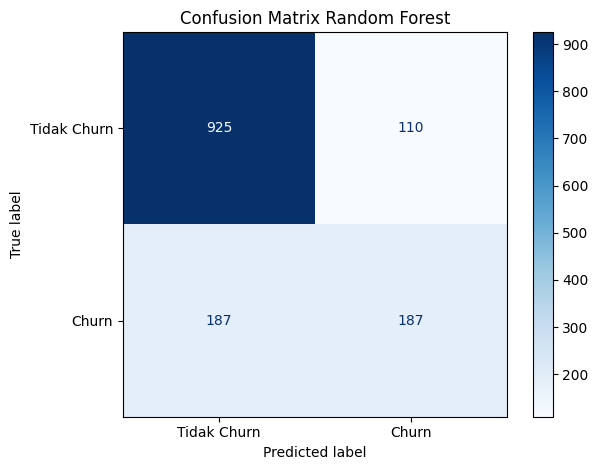

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_te,
    y_pred,
    display_labels=["Tidak Churn", "Churn"],
    cmap="Blues"
)

plt.title("Confusion Matrix Random Forest")
plt.tight_layout()
plt.show()

Kurva ROC

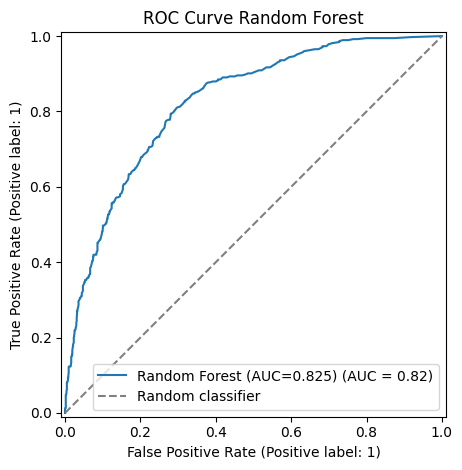

In [14]:
RocCurveDisplay.from_predictions(
    y_te,
    y_prob,
    name=f"Random Forest (AUC={roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.title("ROC Curve Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

Langkah 5 — Prediksi Probabilitas Churn

In [20]:
hasil_prediksi = X_te.copy()

hasil_prediksi["Churn_Aktual"] = y_te.values
hasil_prediksi["Prediksi_Churn"] = y_pred
hasil_prediksi["Probabilitas_Churn"] = y_prob

# Mengurutkan pelanggan berdasarkan risiko churn tertinggi
hasil_prediksi = hasil_prediksi.sort_values(
    "Probabilitas_Churn",
    ascending=False
)

display(
    hasil_prediksi[
        [
            "Churn_Aktual",
            "Prediksi_Churn",
            "Probabilitas_Churn"
        ]
    ].head(10)
)



,Churn_Aktual,Prediksi_Churn,Probabilitas_Churn
1731,1,1,1.000000
2194,1,1,0.993333
809,1,1,0.990000
6623,1,1,0.990000
1739,1,1,0.986667
2927,0,1,0.986667
3346,0,1,0.970000
1144,1,1,0.963333
4585,1,1,0.960000
2729,1,1,0.950000


In [17]:
hasil_prediksi["Kategori_Risiko"] = pd.cut(
    hasil_prediksi["Probabilitas_Churn"],
    bins=[0, 0.3, 0.7, 1.0],
    labels=["Rendah", "Sedang", "Tinggi"],
    include_lowest=True
)

print("Distribusi kategori risiko:")
print(hasil_prediksi["Kategori_Risiko"].value_counts())

Distribusi kategori risiko:
Kategori_Risiko
Rendah    890
Sedang    393
Tinggi    126
Name: count, dtype: int64


## Kesimpulan

Dataset memiliki ketidakseimbangan kelas karena jumlah pelanggan yang tidak
churn lebih banyak dibandingkan pelanggan yang churn. Random Forest dengan
`class_weight="balanced"` digunakan agar model memberikan perhatian lebih
besar kepada kelas churn sebagai kelas minoritas. Recall kelas churn
menunjukkan proporsi pelanggan yang benar-benar churn dan berhasil
dideteksi, sedangkan ROC-AUC menunjukkan kemampuan model dalam membedakan
pelanggan churn dan tidak churn pada berbagai threshold. Probabilitas yang
dihasilkan model dapat digunakan perusahaan untuk menentukan pelanggan
berisiko tinggi yang perlu diprioritaskan dalam program retensi.

In [19]:
print(
    f"Dataset menunjukkan ketidakseimbangan kelas karena pelanggan yang "
    f"tidak churn lebih banyak daripada pelanggan yang churn. Model "
    f"Random Forest memperoleh precision churn sebesar {precision:.3f}, "
    f"recall sebesar {recall:.3f}, dan F1-score sebesar {f1:.3f}. "
    f"Nilai ROC-AUC sebesar {roc_auc:.3f} menunjukkan kemampuan model "
    f"dalam membedakan pelanggan churn dan tidak churn. Pelanggan dengan "
    f"probabilitas churn tertinggi dapat diprioritaskan untuk menerima "
    f"program retensi."
)

Dataset menunjukkan ketidakseimbangan kelas karena pelanggan yang tidak churn lebih banyak daripada pelanggan yang churn. Model Random Forest memperoleh precision churn sebesar 0.630, recall sebesar 0.500, dan F1-score sebesar 0.557. Nilai ROC-AUC sebesar 0.825 menunjukkan kemampuan model dalam membedakan pelanggan churn dan tidak churn. Pelanggan dengan probabilitas churn tertinggi dapat diprioritaskan untuk menerima program retensi.
